# Results SL OOD experiment

/tmp/ipykernel_2122506/3616296916.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  float_vals = auroc_data.replace("N/A", np.nan).applymap(
/tmp/ipykernel_2122506/3616296916.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues_full = cm.get_cmap("Blues", 256)


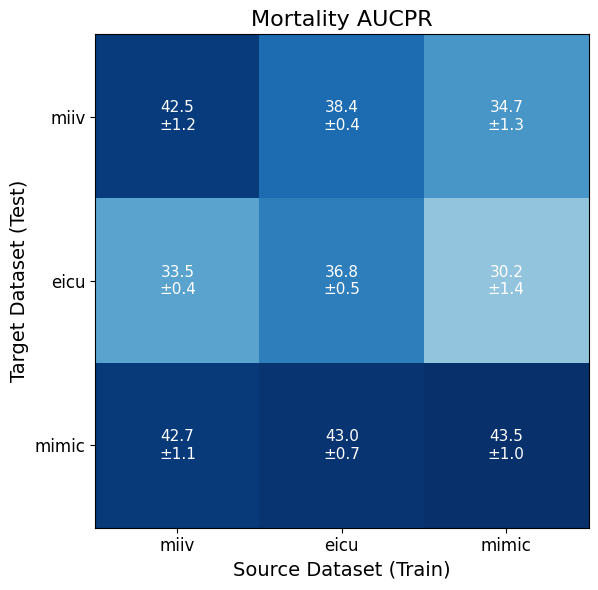

In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# === Choose Metric: "AUC" or "PR" or "loss" ===
metric_name = "PR"  # Change this to "PR" or "loss" as needed

# Display names for titles and labels
metric_display_names = {
    "AUC": "AUCROC",
    "PR": "AUCPR",
    "loss": "Loss"
}

display_name = metric_display_names.get(metric_name, metric_name)


# === Step 1: Define input paths ===
paths = {
    "miiv": "/work3/s185395/yaib_logs/miiv/Mortality24/BAT/2025-06-06T13-17-03/repetition_0",
    "eicu": "/work3/s185395/yaib_logs/eicu/Mortality24/BAT/2025-06-06T13-13-48/repetition_0",
    "mimic": "/work3/s185395/yaib_logs/mimic/Mortality24/BAT/2025-06-06T13-12-21/repetition_0",
}

# === Step 2: Load selected metric values ===
auroc_data = pd.DataFrame(index=paths.keys(), columns=paths.keys())

for source, base_path in paths.items():
    for target in paths.keys():
        if source == target:
            json_path = f"{base_path}/mean_result.json"
        else:
            json_path = f"{base_path}/{target}_mean_results.json"

        try:
            with open(json_path, "r") as f:
                metrics = json.load(f)
                mean = metrics[metric_name]["mean"] * 100
                std = metrics[metric_name]["std"] * 100
                auroc_data.loc[target, source] = f"{mean:.1f}\n±{std:.1f}"
        except Exception as e:
            auroc_data.loc[target, source] = "N/A"
            print(f"⚠️ Failed to load: {json_path}\n{e}")

# === Step 3: Plot heatmap ===
fig, ax = plt.subplots(figsize=(8, 6))
heatmap_values = auroc_data.replace("N/A", np.nan)

float_vals = auroc_data.replace("N/A", np.nan).applymap(
    lambda x: float(x.split("±")[0]) if isinstance(x, str) and "±" in x else np.nan
)

vmin = float_vals.min().min()
vmax = float_vals.max().max()

# Create a truncated "Blues" colormap, keeping only the stronger blue range
blues_full = cm.get_cmap("Blues", 256)
blues_trimmed = ListedColormap(blues_full(np.linspace(0.4, 1.0, 256)))  # avoid 0.0–0.2 (white)

# Draw heatmap
im = ax.imshow(float_vals.values.astype(float), cmap=blues_trimmed, vmin=vmin, vmax=vmax)

# === 🔄 Always use white text
for i in range(len(auroc_data)):
    for j in range(len(auroc_data.columns)):
        value = auroc_data.iloc[i, j]
        if isinstance(value, str) and "±" in value:
            mean, std = value.split("±")
            text = f"{mean.strip()}\n±{std.strip()}"
        else:
            text = value
        ax.text(
            j, i, text,
            ha="center", va="center",
            color="white",  # 👈 always white
            fontsize=11
        )

# Set ticks and labels
ax.set_xticks(np.arange(len(paths)))
ax.set_yticks(np.arange(len(paths)))
ax.set_xticklabels(paths.keys(), fontsize=12)
ax.set_yticklabels(paths.keys(), fontsize=12)
ax.set_xlabel("Source Dataset (Train)", fontsize=14)
ax.set_ylabel("Target Dataset (Test)", fontsize=14)
ax.set_title(f"Mortality {metric_display_names[metric_name]}", fontsize=16)


plt.tight_layout()
plt.show()
